In [1]:
import umap

c:\Users\TUF\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
!pip install seaborn


  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 6.3 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 6.3 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 6.3 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.1 MB 6.2 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 6.3 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.1 MB/s eta 0:00:00
   ----------------------------------


[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: C:\Users\TUF\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [6]:
pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

"""
%matplotlib` inline is a Jupyter magic command that tells 
matplotlib to render plots directly inside the notebook output cells (instead of opening separate windows). 
It works with matplotlib-based plots (including seaborn) so figures show up just below the code that creates them. 
"""

'\n%matplotlib` inline is a Jupyter magic command that tells \nmatplotlib to render plots directly inside the notebook output cells (instead of opening separate windows). \nIt works with matplotlib-based plots (including seaborn) so figures show up just below the code that creates them. \n'

In [8]:
# Set the graphic style for seaborn
sns.set(style='white', context='notebook', rc={'figure.figsize':(14,10)})

In [9]:
import pandas as pd

penguins = pd.read_csv(
    r"C:\Users\TUF\Desktop\Architecture\UCL\Wearbledevice\datacsvrecordings\Final_001.csv"
)

penguins.head()


,Timestamp,Audio_Emotion,Audio_Conf,Text_Sentiment,Text_Conf,Transcript,Timestamp_ms,Time_Str,Lat,Lon,Void,Bio,Tech,Entropy,GSR,MOD
0,2026-01-16 11:02:45,sad,0.92,NEGATIVE,1.00,"I think that's the... Sorry. Yeah, I think we ...",163527.0,11:02:45,45.432610,12.355427,0.68,0.05,0.03,0.24,438.0,1.08
1,2026-01-16 11:02:53,sad,0.97,NEGATIVE,0.96,fast because like the machine needs time to re...,170507.0,11:02:52,45.432631,12.355433,0.76,0.06,0.13,0.05,434.0,1.08
2,2026-01-16 11:03:01,sad,0.91,NEGATIVE,1.00,How many doors are there? So now a lot of door...,177545.0,11:02:59,45.432575,12.355507,0.01,0.03,0.95,0.01,436.0,1.08
3,2026-01-16 11:03:09,sad,0.82,NEGATIVE,1.00,"Yeah, yeah, so like is there meaning this loca...",184654.0,11:03:06,45.432592,12.355584,0.62,0.09,0.01,0.28,435.0,1.08
4,2026-01-16 11:03:17,sad,0.91,POSITIVE,0.96,of this location for you? um this location yes...,191829.0,11:03:14,45.432620,12.355655,0.13,0.20,0.45,0.21,442.0,1.08


In [10]:
penguins = penguins.dropna()
# Check the distribution of species in the dataset
penguins.species.value_counts()

AttributeError: 'DataFrame' object has no attribute 'species'

File loaded successfully!
Calculating UMAP coordinates...


c:\Users\TUF\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\TUF\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved 2D plot as umap_2d_visualization.png
Saved 3D plot as umap_3d_visualization.png
Results saved to transformed_valence_umap_result.csv


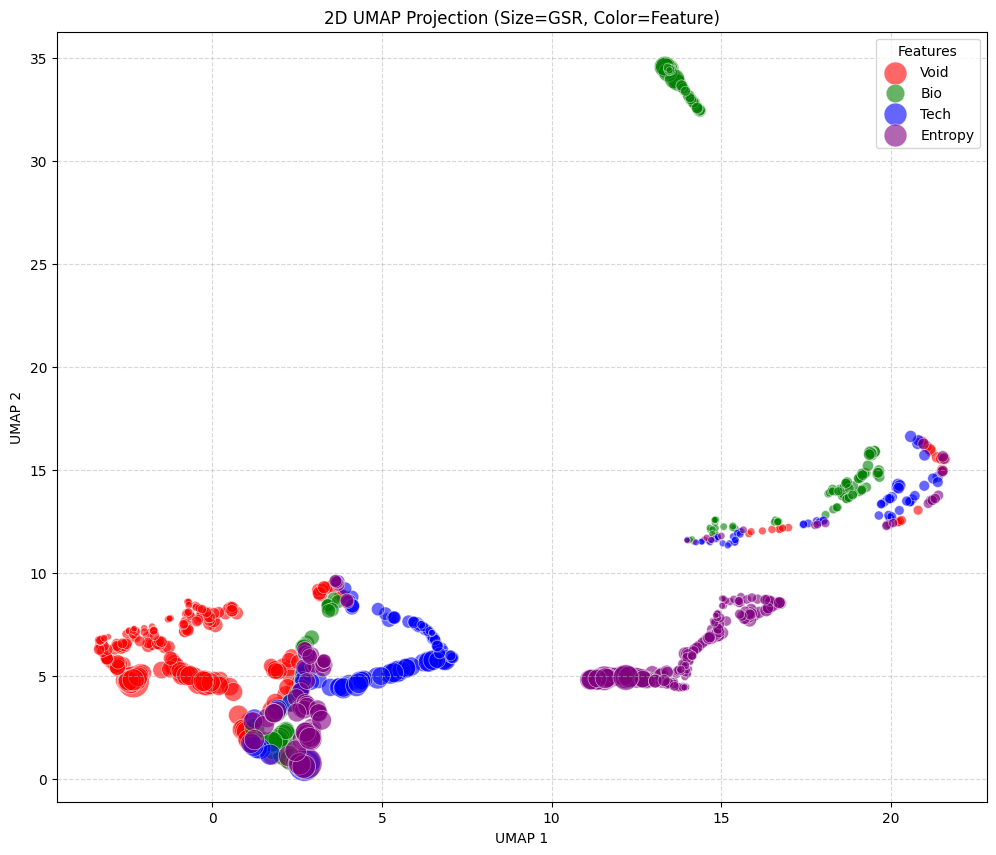

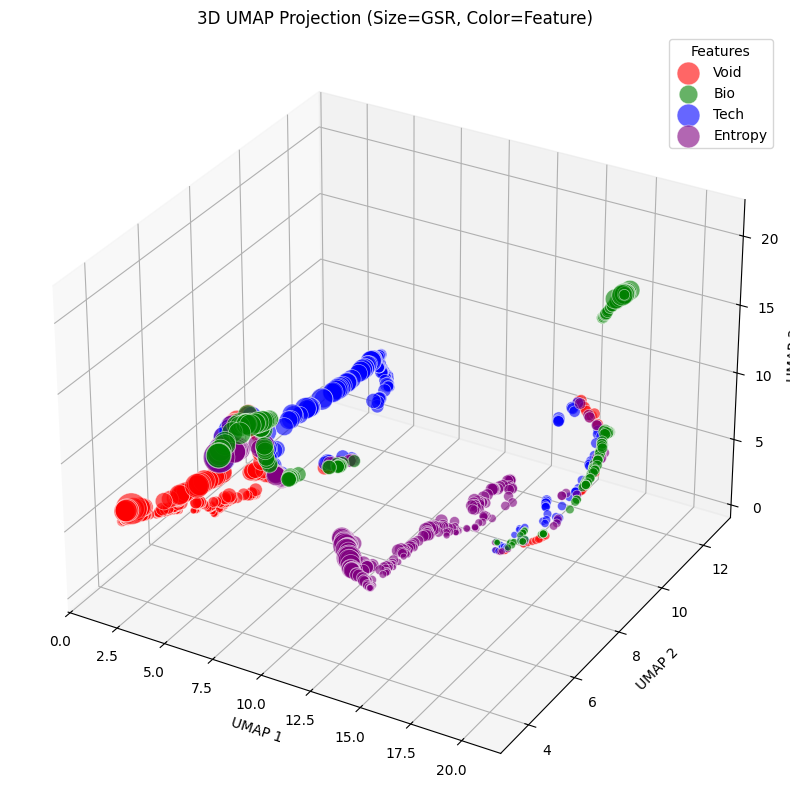

In [3]:
import pandas as pd
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Load the transformed data
# Fixed path: Removed the double nested quotes
input_file = r'C:\Users\TUF\Desktop\Architecture\UCL\Wearbledevice\datacsvrecordings\transformed_valence_data.csv'

try:
    df = pd.read_csv(input_file)
    print("File loaded successfully!")
except FileNotFoundError:
    print(f"Error: The file was not found at {input_file}")
    # Fallback to local if the absolute path fails
    df = pd.read_csv('transformed_valence_data.csv')

# 2. Identify the category for each row for coloring
# Since our transformation set only one feature to non-zero per row
def get_category(row):
    if row['Void'] > 0: return 'Void'
    if row['Bio'] > 0: return 'Bio'
    if row['Tech'] > 0: return 'Tech'
    if row['Entropy'] > 0: return 'Entropy'
    return 'None'

df['Category'] = df.apply(get_category, axis=1)

# 3. Prepare features for UMAP calculation
features = ['Void', 'Bio', 'Tech', 'Entropy', 'GSR']
data_clean = df[features].dropna()
scaled_data = StandardScaler().fit_transform(data_clean)

# 4. Perform UMAP
print("Calculating UMAP coordinates...")
# 2D Projection
reducer_2d = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
embedding_2d = reducer_2d.fit_transform(scaled_data)
df['UMAP_2D_1'] = embedding_2d[:, 0]
df['UMAP_2D_2'] = embedding_2d[:, 1]

# 3D Projection
reducer_3d = umap.UMAP(n_components=3, n_neighbors=30, min_dist=0.1, random_state=42)
embedding_3d = reducer_3d.fit_transform(scaled_data)
df['UMAP_3D_1'] = embedding_3d[:, 0]
df['UMAP_3D_2'] = embedding_3d[:, 1]
df['UMAP_3D_3'] = embedding_3d[:, 2]

# 5. Define Visualization Parameters (Enhanced Sizing)
category_colors = {'Void': 'red', 'Bio': 'green', 'Tech': 'blue', 'Entropy': 'purple'}

# Normalize GSR and apply a power transformation to exaggerate differences
# We subtract the min to start at 0, then square it to make higher values much larger
gsr_normalized = (df['GSR'] - df['GSR'].min()) / (df['GSR'].max() - df['GSR'].min())
sizes = (gsr_normalized ** 2) * 500 + 20  # Squaring makes the contrast much higher

# 6. Plot 2D UMAP
plt.figure(figsize=(12, 10))
for cat, color in category_colors.items():
    mask = df['Category'] == cat
    plt.scatter(df.loc[mask, 'UMAP_2D_1'], df.loc[mask, 'UMAP_2D_2'], 
                s=sizes[mask], c=color, label=cat, alpha=0.6, edgecolors='w', linewidth=0.5)

plt.title('2D UMAP Projection (Size=GSR, Color=Feature)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title="Features")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('umap_2d_visualization.png')
print("Saved 2D plot as umap_2d_visualization.png")

# 7. Plot 3D UMAP
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
for cat, color in category_colors.items():
    mask = df['Category'] == cat
    ax.scatter(df.loc[mask, 'UMAP_3D_1'], df.loc[mask, 'UMAP_3D_2'], df.loc[mask, 'UMAP_3D_3'],
               s=sizes[mask], c=color, label=cat, alpha=0.6, edgecolors='w', linewidth=0.5)

ax.set_title('3D UMAP Projection (Size=GSR, Color=Feature)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
ax.legend(title="Features")
plt.savefig('umap_3d_visualization.png')
print("Saved 3D plot as umap_3d_visualization.png")

# 8. Export result to CSV
output_file = 'transformed_valence_umap_result.csv'
df.to_csv(output_file, index=False)
print(f"Results saved to {output_file}")